In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

In [2]:
data_dir = Path("../data/raw")

X = pd.read_csv(
    data_dir / "secom.data",
    sep=r"\s+",
    header=None,
    na_values="NaN"
)

y = pd.read_csv(
    data_dir / "secom_labels.data",
    sep=r"\s+",
    header=None
)

missing_ratio = X.isna().mean()
high_missing_features = missing_ratio[missing_ratio >= 0.5].index

X_reduced = X.drop(columns=high_missing_features)
X_clean = X_reduced.fillna(X_reduced.median())

feature_variance = X_clean.var()
zero_variance_features = feature_variance[feature_variance == 0].index

X_clean = X_clean.drop(columns=zero_variance_features)

scaler = StandardScaler()

X_scaled_array = scaler.fit_transform(X_clean)

X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=X_clean.columns,
    index=X_clean.index
)

print("X_clean shape:", X_clean.shape)
print("X_scaled shape:", X_scaled.shape)
print("y shape:", y.shape)

X_clean shape: (1567, 446)
X_scaled shape: (1567, 446)
y shape: (1567, 2)


In [3]:
pass_mask = y[0] == -1 
fail_mask = y[0] == 1

pass_mean = X_clean[pass_mask].mean()
fail_mean = X_clean[fail_mask].mean()
overall_std = X_clean.std()

standardized_diff = (fail_mean - pass_mean) / overall_std
abs_standardized_diff = standardized_diff.abs()

mean_diff_ranking = pd.DataFrame({
    "feature": abs_standardized_diff.index,
    "pass_mean": pass_mean,
    "fail_mean": fail_mean,
    "difference": fail_mean - pass_mean,
    "standardized_difference": standardized_diff,
    "abs_standardized_difference": abs_standardized_diff,
})

mean_diff_ranking = (
    mean_diff_ranking
    .sort_values("abs_standardized_difference", ascending=False)
    .reset_index(drop=True)
)

print("Pass/Fail 평균 차이 기반 상위 15개 feature:")
print(mean_diff_ranking.head(15))

Pass/Fail 평균 차이 기반 상위 15개 feature:
    feature    pass_mean    fail_mean  difference  standardized_difference  \
0        59     2.555731     8.515123    5.959392                 0.626524   
1       103    -0.009913    -0.008053    0.001860                 0.607336   
2       510    54.430401    74.347949   19.917548                 0.528752   
3       348     0.024263     0.030448    0.006185                 0.525317   
4       431    21.187933    38.707342   17.519410                 0.481663   
5       434    13.716830    28.954783   15.237952                 0.447025   
6       430    17.364169    33.156115   15.791946                 0.438203   
7        21 -5636.360219 -5363.822115  272.538103                 0.435065   
8       435     8.373389    23.306973   14.933584                 0.434770   
9        28    69.597730    68.111542   -1.486188                -0.429659   
10      436     6.530367    21.248687   14.718319                 0.426171   
11      210     0.087575     

In [4]:
spc_features = mean_diff_ranking["feature"].head(15).tolist()

spc_feature_impact = []

for feature in spc_features:
    values = X_clean[feature]

    cl = values.mean()
    std = values.std()
    ucl = cl + 3 * std
    lcl = cl - 3 * std

    spc_alert = (values > ucl) | (values < lcl)

    total_alerts = spc_alert.sum()
    fail_alerts = ((y[0] == 1) & spc_alert).sum()
    pass_alerts = ((y[0] == -1) & spc_alert).sum()

    alert_fail_ratio = fail_alerts / total_alerts if total_alerts > 0 else 0
    fail_capture_rate = fail_alerts / (y[0] == 1).sum()

    spc_feature_impact.append({
        "feature": feature,
        "total_alerts": total_alerts,
        "fail_alerts": fail_alerts,
        "pass_alerts": pass_alerts,
        "alert_fail_ratio": alert_fail_ratio,
        "fail_capture_rate": fail_capture_rate,
    })

spc_feature_impact_df = (
    pd.DataFrame(spc_feature_impact)
    .sort_values(["fail_alerts", "alert_fail_ratio"], ascending=False)
    .reset_index(drop=True)
)

print("SPC 기반 feature impact:")
print(spc_feature_impact_df)

SPC 기반 feature impact:
    feature  total_alerts  fail_alerts  pass_alerts  alert_fail_ratio  \
0       510            32            7           25          0.218750   
1       431            32            7           25          0.218750   
2       434            32            7           25          0.218750   
3       430            32            7           25          0.218750   
4       435            32            7           25          0.218750   
5       436            32            7           25          0.218750   
6       298            32            7           25          0.218750   
7       163            32            7           25          0.218750   
8        21            24            6           18          0.250000   
9       348            24            4           20          0.166667   
10      210            28            4           24          0.142857   
11      103             7            2            5          0.285714   
12       59             5   

In [5]:
fail_ratio = (y[0] == 1).mean()

iso_forest = IsolationForest(
    contamination=fail_ratio,
    random_state=42,
)

iso_forest.fit(X_scaled)

anomaly_score = iso_forest.decision_function(X_scaled)

ml_result = pd.DataFrame({
    "label": y[0],
    "timestamp": y[1],
    "anomaly_score": anomaly_score,
})

ml_cutoff = ml_result["anomaly_score"].quantile(0.05)
ml_alert = ml_result["anomaly_score"] <= ml_cutoff

ml_alert_mean = X_clean[ml_alert].mean()
ml_normal_mean = X_clean[~ml_alert].mean()
ml_overall_std = X_clean.std()

ml_standardized_diff = (ml_alert_mean - ml_normal_mean) / ml_overall_std
ml_abs_standardized_diff = ml_standardized_diff.abs()

ml_feature_impact = pd.DataFrame({
    "feature": ml_abs_standardized_diff.index,
    "ml_alert_mean": ml_alert_mean,
    "ml_normal_mean": ml_normal_mean,
    "difference": ml_alert_mean - ml_normal_mean,
    "standardized_difference": ml_standardized_diff,
    "abs_standardized_difference": ml_abs_standardized_diff,
})

ml_feature_impact = (
    ml_feature_impact
    .sort_values("abs_standardized_difference", ascending=False)
    .reset_index(drop=True)
)

print("ML anomaly 그룹 기준 feature impact 상위 15개:")
print(ml_feature_impact.head(15))

ML anomaly 그룹 기준 feature impact 상위 15개:
    feature  ml_alert_mean  ml_normal_mean   difference  \
0       300       0.596215        0.092970     0.503245   
1       164       0.656215        0.099843     0.556372   
2       165       1.138835        0.204852     0.933983   
3       299       0.344735        0.045137     0.299599   
4       298       0.199732        0.056573     0.143159   
5       163       0.394595        0.126671     0.267924   
6       434      84.391034       11.029656    73.361378   
7       435      79.241287        5.654659    73.586629   
8       436      77.720123        3.779503    73.940620   
9       430      89.473034       14.639547    74.833487   
10      431      93.718608       18.561653    75.156955   
11      294    1263.919943      355.878866   908.041077   
12       26       1.599778        1.956523    -0.356745   
13      159    2599.379747      791.189516  1808.190231   
14      295     705.319238      228.907965   476.411273   

    standardize

In [6]:
mean_diff_top = set(mean_diff_ranking["feature"].head(15))
spc_top = set(spc_feature_impact_df["feature"].head(15))
ml_top = set(ml_feature_impact["feature"].head(15))

all_candidate_features = sorted(mean_diff_top | spc_top | ml_top)

feature_summary = []

for feature in all_candidate_features:
    in_mean_diff = feature in mean_diff_top
    in_spc = feature in spc_top
    in_ml = feature in ml_top

    score = int(in_mean_diff) + int(in_spc) + int(in_ml)

    feature_summary.append({
        "feature": feature,
        "in_pass_fail_mean_diff_top15": in_mean_diff,
        "in_spc_impact_top15": in_spc,
        "in_ml_anomaly_top15": in_ml,
        "combined_score": score,
    })

feature_summary_df = (
    pd.DataFrame(feature_summary)
    .sort_values(["combined_score", "feature"], ascending=[False, True])
    .reset_index(drop=True)
)

print("종합 주요 feature 후보:")
print(feature_summary_df)

종합 주요 feature 후보:
    feature  in_pass_fail_mean_diff_top15  in_spc_impact_top15  \
0       163                          True                 True   
1       298                          True                 True   
2       430                          True                 True   
3       431                          True                 True   
4       434                          True                 True   
5       435                          True                 True   
6       436                          True                 True   
7        21                          True                 True   
8        28                          True                 True   
9        59                          True                 True   
10      103                          True                 True   
11      129                          True                 True   
12      210                          True                 True   
13      348                          True                 

In [7]:
top_feature_candidates = feature_summary_df[
    feature_summary_df["combined_score"] >= 2
]["feature"].tolist()

final_feature_impact = feature_summary_df[
    feature_summary_df["feature"].isin(top_feature_candidates)
].copy()

final_feature_impact = final_feature_impact.merge(
    mean_diff_ranking[[
        "feature",
        "standardized_difference",
        "abs_standardized_difference",
    ]],
    on="feature",
    how="left",
)

final_feature_impact = final_feature_impact.merge(
    spc_feature_impact_df[[
        "feature",
        "total_alerts",
        "fail_alerts",
        "alert_fail_ratio",
    ]],
    on="feature",
    how="left",
)

final_feature_impact = final_feature_impact.merge(
    ml_feature_impact[[
        "feature",
        "standardized_difference",
        "abs_standardized_difference",
    ]].rename(columns={
        "standardized_difference": "ml_standardized_difference",
        "abs_standardized_difference": "ml_abs_standardized_difference",
    }),
    on="feature",
    how="left",
)

final_feature_impact = (
    final_feature_impact
    .sort_values(["combined_score", "fail_alerts", "ml_abs_standardized_difference"], ascending=False)
    .reset_index(drop=True)
)

print("최종 주요 feature impact 표:")
print(final_feature_impact)

최종 주요 feature impact 표:
    feature  in_pass_fail_mean_diff_top15  in_spc_impact_top15  \
0       298                          True                 True   
1       163                          True                 True   
2       434                          True                 True   
3       435                          True                 True   
4       436                          True                 True   
5       430                          True                 True   
6       431                          True                 True   
7       510                          True                 True   
8        21                          True                 True   
9       348                          True                 True   
10      210                          True                 True   
11      103                          True                 True   
12       59                          True                 True   
13       28                          True           

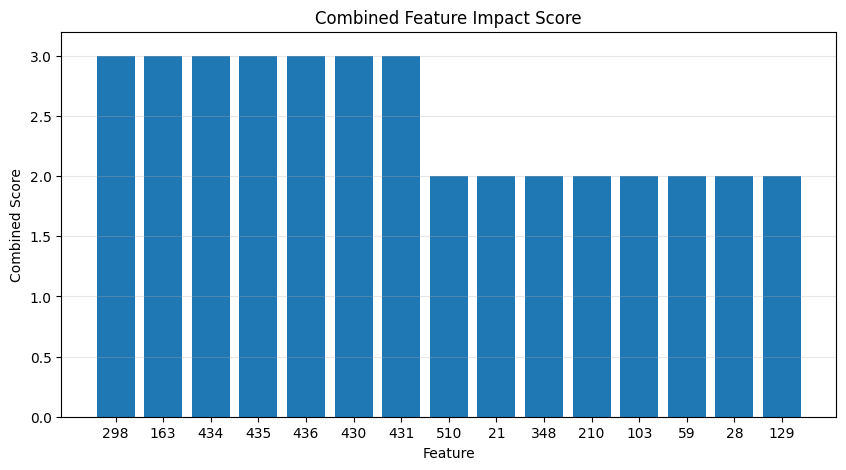

In [8]:
plt.figure(figsize=(10, 5))

plot_features = final_feature_impact.head(15).copy()
plot_features["feature"] = plot_features["feature"].astype(str)

plt.bar(
    plot_features["feature"],
    plot_features["combined_score"],
)

plt.title("Combined Feature Impact Score")
plt.xlabel("Feature")
plt.ylabel("Combined Score")
plt.ylim(0, 3.2)
plt.grid(axis="y", alpha=0.3)
plt.show()

## Feature Impact Analysis Summary

This notebook identified key feature candidates related to fail and anomaly behavior in the SECOM dataset.

### Feature Impact Criteria

Feature impact was analyzed using three criteria:

1. Pass/fail mean difference
2. SPC-based feature impact
3. ML anomaly group feature difference

### 1. Pass/Fail Mean Difference

For each feature, the mean value of pass samples and fail samples was compared.

Because each feature has a different scale, standardized mean difference was used:

```text
standardized difference = (fail mean - pass mean) / overall standard deviation